In [6]:
import os, json, pathlib, urllib.request
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models, Input, regularizers
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input, decode_predictions
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import image_dataset_from_directory, get_file
from tensorflow.keras.preprocessing import image as keras_image
from tensorflow.keras.models import load_model
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

In [7]:
SEED = 42
tf.keras.utils.set_random_seed(SEED)

In [40]:
IMAGE_SIZE = (224, 224) # MobileNetV2 native input
BATCH_SIZE = 32
EPOCH_STAGE1 = 5 # frozen-backbone warm up
EPOCH_STAGE2 = 3 # fine-tuning
FINE_TUNE_AT = 120 # unfreeze layers from this index onwards
INIT_LR = 1e-3
FINE_TUNE_LR = 1e-5
VAL_SPLIT = 0.2
DATA_PATH = "/content/drive/MyDrive/Deep Learning and Artificial Neural Networks/Exercise 9/data"

Load the dataset

In [10]:
train_ds = image_dataset_from_directory(DATA_PATH,
                                        image_size=IMAGE_SIZE, batch_size=BATCH_SIZE,
                                        validation_split=VAL_SPLIT, subset="training", seed=SEED)

val_ds = image_dataset_from_directory(DATA_PATH,
                                      image_size=IMAGE_SIZE, batch_size=BATCH_SIZE,
                                      validation_split=VAL_SPLIT, subset='validation', seed=SEED)

Found 21 files belonging to 2 classes.
Using 17 files for training.
Found 21 files belonging to 2 classes.
Using 4 files for validation.


In [11]:
class_names = train_ds.class_names
num_classes = len(class_names)
print("Classes:, ", class_names)

Classes:,  ['cat', 'dog']


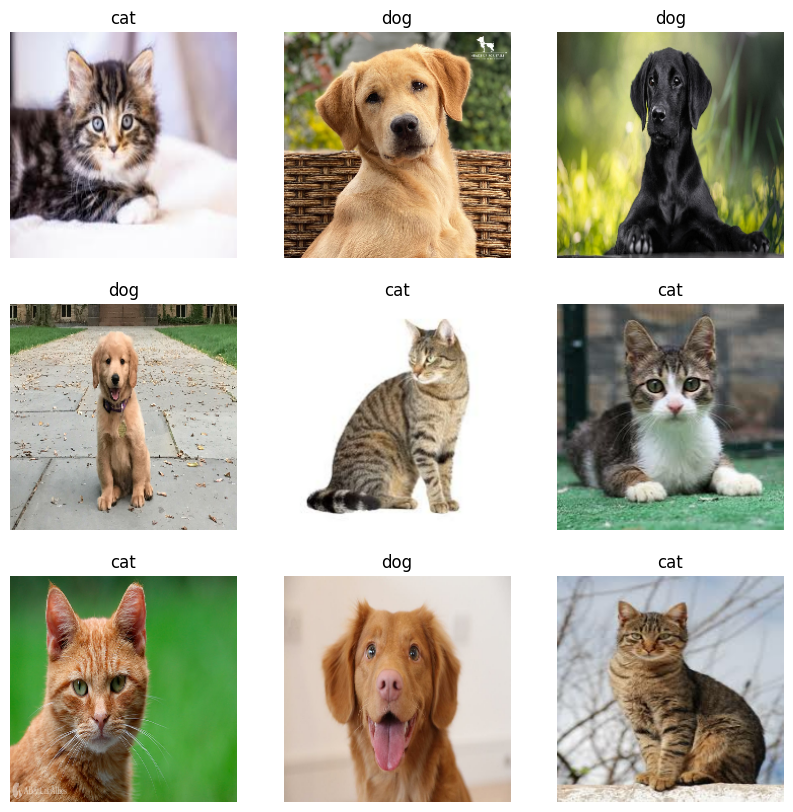

In [12]:
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
  for i in range(min(9, images.shape[0])):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(class_names[labels[i]])
    plt.axis("off")

plt.show()

Pretrained Inference

In [17]:
def fetch_image(url, filename):
    import urllib.request
    dest = pathlib.Path("/tmp") / filename
    if not dest.exists():
        req = urllib.request.Request(url, headers={"User-Agent": "Mozilla/5.0"})
        with urllib.request.urlopen(req) as r:
            dest.write_bytes(r.read())
    return str(dest)

35363/35363 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Top-3 ImageNet predictions:
 African_elephant          45.49%
 tusker                    12.41%
 Indian_elephant            6.95%


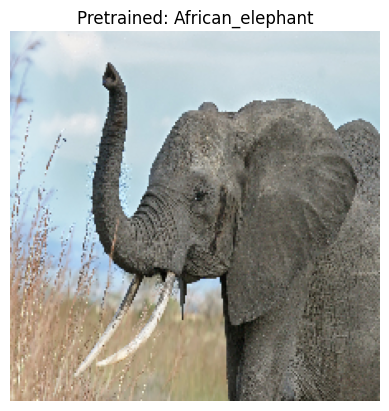

In [20]:
imagenet_model = MobileNetV2(weights='imagenet') # include_top=True by default
img_url = "https://upload.wikimedia.org/wikipedia/commons/6/63/African_elephant_warning_raised_trunk.jpg"
img_path = fetch_image(img_url, 'elephant.jpg')

img = keras_image.load_img(img_path, target_size=(224, 224))
img_array = keras_image.img_to_array(img)
img_array = preprocess_input(img_array)
img_array = np.expand_dims(img_array, axis=0)

preds = imagenet_model.predict(img_array, verbose=0)
decoded = decode_predictions(preds, top=3)[0]

print("Top-3 ImageNet predictions:")
for _, label, prob in decoded:
  print(f" {label:25s} {prob*100:5.2f}%")

plt.imshow(img)
plt.axis("off")
plt.title(f"Pretrained: {decoded[0][1]}")
plt.show()

Random head

In [21]:
backbone = MobileNetV2(input_shape=(224, 224, 3), include_top=False, weights="imagenet")
backbone.trainable = False

inp = Input(shape=(224, 224, 3))
x = preprocess_input(inp)
x = backbone(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
out = layers.Dense(1000, activation="softmax")(x) # randomly initialized


random_head_model = models.Model(inp, out)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [23]:
raw = keras_image.img_to_array(keras_image.load_img(img_path, target_size=(224, 224)))
raw_batch = np.expand_dims(raw, axis=0)

preds = random_head_model.predict(raw_batch, verbose=0)
print("Random-head top-3: ")
for _, label, prob in decode_predictions(preds, top=3)[0]:
  print(f"{label:25s} {prob*100:5.2f}%")

Random-head top-3: 
damselfly                  0.31%
caldron                    0.31%
American_black_bear        0.30%


Frozen backbone

In [24]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
], name="data_augmentation")

In [25]:
backbone = MobileNetV2(input_shape=(224, 224, 3), include_top=False, weights='imagenet')
backbone.trainable = False # freezing the entire backbone

In [35]:
inp = Input(shape=(224, 224, 3))
x = data_augmentation(inp)
x = preprocess_input(x)
x = backbone(x,training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0)(x)
out = layers.Dense(num_classes, activation="softmax")(x)

In [36]:
model = models.Model(inp, out, name="mobilenetv2_transfer")

model.compile(optimizer=tf.keras.optimizers.Adam(INIT_LR), loss="sparse_categorical_crossentropy", metrics=['accuracy'])

model.summary()

Model: "mobilenetv2_transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_10 (InputLayer)     │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_2 (TrueDivide)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract_2 (Subtract)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_7      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │         2,562 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,260,546 (8.62 MB)

 Trainable params: 2,562 (10.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [37]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6)
    ]

history_stage1 = model.fit(train_ds, validation_data=val_ds, epochs=EPOCH_STAGE1, callbacks=callbacks)

Epoch 1/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 8s 8s/step - accuracy: 0.8235 - loss: 0.5200 - val_accuracy: 1.0000 - val_loss: 0.3275 - learning_rate: 0.0010
Epoch 2/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.8235 - loss: 0.4212 - val_accuracy: 1.0000 - val_loss: 0.2599 - learning_rate: 0.0010
Epoch 3/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.9412 - loss: 0.2891 - val_accuracy: 1.0000 - val_loss: 0.2135 - learning_rate: 0.0010
Epoch 4/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 1.0000 - loss: 0.2350 - val_accuracy: 1.0000 - val_loss: 0.1776 - learning_rate: 0.0010
Epoch 5/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 1.0000 - loss: 0.1469 - val_accuracy: 1.0000 - val_loss: 0.1492 - learning_rate: 0.0010


In [33]:
def plot_history(h, title_suffix=""):
  fig, axes = plt.subplots(1, 2, figsize=(12, 4))
  axes[0].plot(h.history['loss'], label='train')
  axes[0].plot(h.history['val_loss'], label='val')
  axes[0].set_title(f"Loss {title_suffix}")
  axes[0].set_xlabel("epoch")
  axes[0].legend()

  axes[1].plot(h.history['accuracy'], label='train')
  axes[1].plot(h.history['val_accuracy'], label='val')
  axes[1].set_title(f"Accuracy {title_suffix}")
  axes[1].set_xlabel("epoch")
  axes[1].legend()
  plt.tight_layout()
  plt.show()

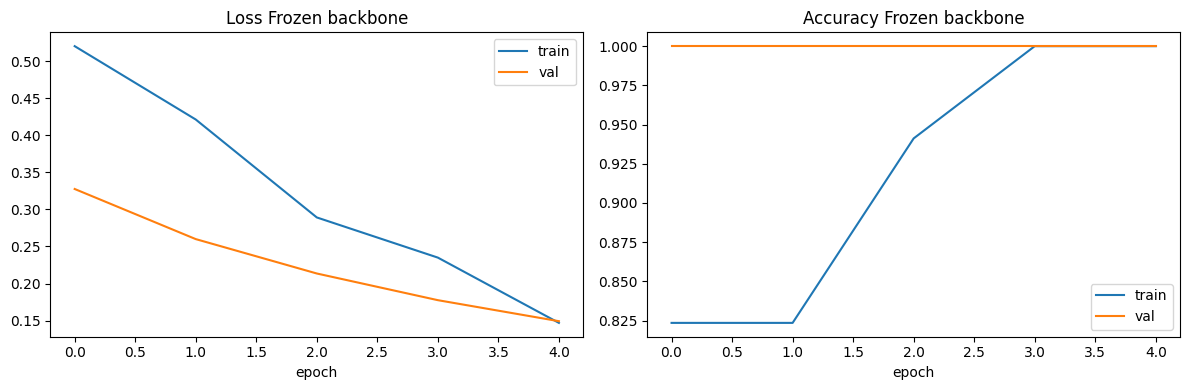

In [38]:
plot_history(history_stage1, "Frozen backbone")

Unfreeze top layers

In [41]:
backbone.trainable = True
print(f"Backbone has {len(backbone.layers)} layers. Unfreezing from layer {FINE_TUNE_AT} onward.")

Backbone has 154 layers. Unfreezing from layer 120 onward.


If you want to retrain the entire model backbone is also trainable, True, if only a part of the backbone then it follows:

Make sure first 120 layers are frozen, not trainable

In [42]:
for layer in backbone.layers[:FINE_TUNE_AT]:
  layer.trainable = False

In [44]:
model.compile(optimizer=tf.keras.optimizers.Adam(FINE_TUNE_LR), loss="sparse_categorical_crossentropy", metrics=['accuracy'])

In [45]:
trainable_params = sum([tf.size(v).numpy() for v in model.trainable_variables])
print(f"Trainable params now: {trainable_params}")

Trainable params now: 1627458


In [47]:
history_stage2 = model.fit(train_ds, validation_data=val_ds, epochs=EPOCH_STAGE1 + EPOCH_STAGE2, initial_epoch=history_stage1.epoch[-1] + 1,
                           callbacks=callbacks)

Epoch 6/8
1/1 ━━━━━━━━━━━━━━━━━━━━ 23s 23s/step - accuracy: 0.9412 - loss: 0.2111 - val_accuracy: 1.0000 - val_loss: 0.1462 - learning_rate: 1.0000e-05
Epoch 7/8
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - accuracy: 0.9412 - loss: 0.1777 - val_accuracy: 1.0000 - val_loss: 0.1432 - learning_rate: 1.0000e-05
Epoch 8/8
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 1.0000 - loss: 0.1695 - val_accuracy: 1.0000 - val_loss: 0.1404 - learning_rate: 1.0000e-05


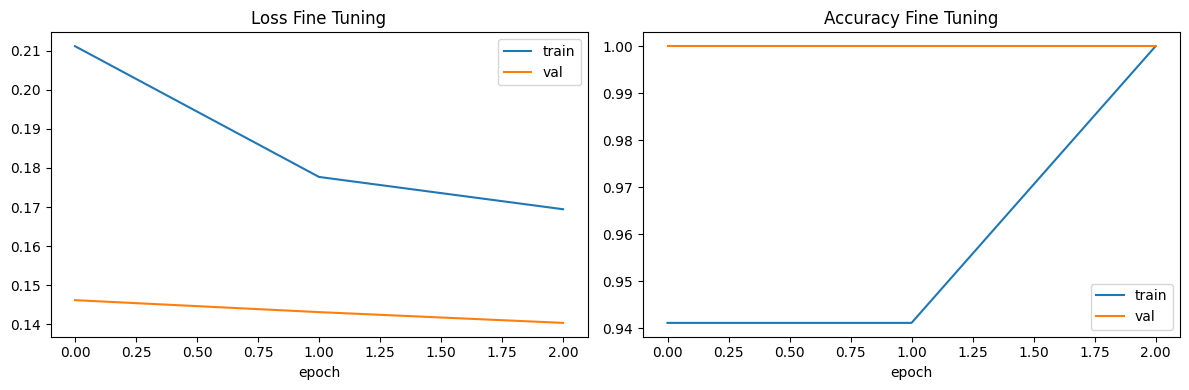

In [48]:
plot_history(history_stage2, "Fine Tuning")

Save and export to ONNX

In [49]:
model.save("model.keras")

In [51]:
!pip install onnx

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.6/17.6 MB 45.4 MB/s eta 0:00:00


In [52]:
import onnx

In [55]:
!pip install -U tf2onnx onnxruntime

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 839.1/839.1 kB 13.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 39.6 MB/s eta 0:00:00


In [57]:
import tf2onnx

In [60]:
spec = (tf.TensorSpec((None, 224, 224, 3), tf.float32, name='input'),)
tf2onnx.convert.from_keras(model, input_signature=spec, output_path="model.onnx")
print('Model exported to onnx')

Model exported to onnx


In [61]:
import onnxruntime as ort
from PIL import Image

In [62]:
test_url = "https://upload.wikimedia.org/wikipedia/commons/thumb/1/15/Cat_August_2010-4.jpg/500px-Cat_August_2010-4.jpg"
test_path = fetch_image(test_url, "test.jpg")


In [63]:
img = Image.open(test_path).convert("RGB").resize(IMAGE_SIZE)
img_array = np.array(img, dtype=np.float32)
img_batch = np.expand_dims(img_array, axis=0)

In [64]:
session = ort.InferenceSession("model.onnx", providers=["CPUExecitionProvider"])
input_name = session.get_inputs()[0].name
onnx_preds = session.run(None, {input_name: img_batch})[0]
onnx_class = int(np.argmax(onnx_preds[0]))

tf_preds = model.predict(img_batch, verbose=0)
tf_class = int(np.argmax(tf_preds[0]))

/usr/local/lib/python3.12/dist-packages/onnxruntime/capi/onnxruntime_inference_collection.py:123: UserWarning: Specified provider 'CPUExecitionProvider' is not in available provider names.Available providers: 'AzureExecutionProvider, CPUExecutionProvider'
  warnings.warn(


*************** EP Error ***************
EP Error Unknown Provider Type: CPUExecitionProvider when using ['CPUExecitionProvider']
Falling back to ['CPUExecutionProvider'] and retrying.
****************************************


TF prediction: cat (77.4)%
ONNX prediction: cat (77.4)%


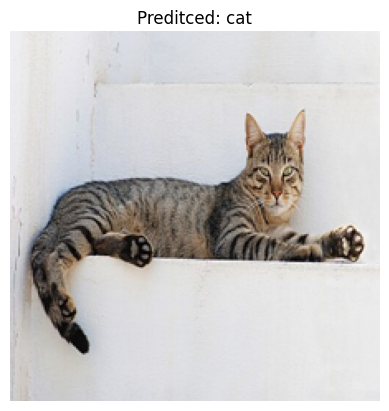

In [65]:
print(f'TF prediction: {class_names[tf_class]} ({tf_preds[0][tf_class]*100:.1f})%')
print(f'ONNX prediction: {class_names[onnx_class]} ({onnx_preds[0][onnx_class]*100:.1f})%')

plt.imshow(img)
plt.axis('off')
plt.title(f'Preditced: {class_names[onnx_class]}')
plt.show()